#

# Exercise 1: Advanced Data Visualizations and Deployment


#

# Tasks:
1.Download the training, validation, and test data.

2.Develop the software to:

 -EDA (at least 4)

 -Preprocess

 -Train

 -Predict

3.Develop the software to perform inference given a random image from the user.

4.Develop a streamlit app to deploy to HuggingFace. The app should:

 -Show several example images from the dataset.

 -Show several EDA figures.
  
 -Allow the user to upload an image and provide a classification for it.

 -Show metrics about model performance.


# Instalación de Dependencias

In [1]:
!pip install -q tensorflow matplotlib seaborn scikit-learn pandas numpy Pillow tqdm gdown

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import os
import pickle
import gdown
import zipfile
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load Data


> - Training: https://drive.google.com/open?id=1ZrJJvIbZ5vUHjyzUGNXGI4sRS7zlU5Db
> - Validation: https://drive.google.com/open?id=1bLWaYJZHroOyfPVscVdBjh9atjvHDdFj
> - Test: https://drive.google.com/open?id=127Usik6jjD_oBhr5hDojgLARW9XYxWdr

In [4]:
import pickle
import os

# Removed gdown and zipfile operations as per user request to use pickle.
# Data will now be loaded directly from .p files.

print("Loading .p files using pickle...")

# Check if .p files exist in /content/
if not os.path.exists('/content/train.p') or \
   not os.path.exists('/content/valid.p') or \
   not os.path.exists('/content/test.p'):
    print("Warning: One or more .p files (train.p, valid.p, test.p) not found in /content/.")
    print("Please ensure these files are uploaded to the Colab environment.")
else:
    with open('/content/train.p', 'rb') as f:
        train_data = pickle.load(f)
    with open('/content/valid.p', 'rb') as f:
        valid_data = pickle.load(f)
    with open('/content/test.p', 'rb') as f:
        test_data = pickle.load(f)

    # Assuming .p files contain dictionaries with 'features' (images) and 'labels'
    # Adjust this if the structure is different
    if isinstance(train_data, dict) and 'features' in train_data and 'labels' in train_data:
        X_train, y_train = train_data['features'], train_data['labels']
        X_valid, y_valid = valid_data['features'], valid_data['labels']
        X_test, y_test = test_data['features'], test_data['labels']

        print(f"Train data loaded: X_train shape {X_train.shape}, y_train shape {y_train.shape}")
        print(f"Valid data loaded: X_valid shape {X_valid.shape}, y_valid shape {y_valid.shape}")
        print(f"Test data loaded: X_test shape {X_test.shape}, y_test shape {y_test.shape}")

        # Now the data is in X_train, y_train, etc.
        # The variables TRAIN_PATH, VALID_PATH, TEST_PATH (defined in the next cell)
        # will no longer be used by ImageDataGenerator.flow_from_directory,
        # and EDA functions will need to be adapted to use X_train, y_train directly.
        # I will leave the definition of TRAIN_PATH, etc., as is for now,
        # but be aware that their usage in subsequent cells will need modification.

    else:
        print("Warning: .p file format not as expected (dictionary with 'features' and 'labels').")
        print("Please inspect the content of the .p files to proceed.")

Loading .p files using pickle...
Train data loaded: X_train shape (34799, 32, 32, 3), y_train shape (34799,)
Valid data loaded: X_valid shape (4410, 32, 32, 3), y_valid shape (4410,)
Test data loaded: X_test shape (12630, 32, 32, 3), y_test shape (12630,)


In [5]:
# ─── CONFIGURACIÓN DE RUTAS ───
# Ajusta estas rutas según la estructura real de los archivos descargados
TRAIN_PATH = 'data/train'   # carpeta con subcarpetas 0-42
VALID_PATH = 'data/valid'
TEST_PATH  = 'data/test'

# Nombres de las 43 clases (señales de tráfico alemanas)
CLASS_NAMES = [
    'Speed limit (20km/h)', 'Speed limit (30km/h)', 'Speed limit (50km/h)',
    'Speed limit (60km/h)', 'Speed limit (70km/h)', 'Speed limit (80km/h)',
    'End of speed limit (80km/h)', 'Speed limit (100km/h)', 'Speed limit (120km/h)',
    'No passing', 'No passing veh over 3.5 tons', 'Right-of-way at intersection',
    'Priority road', 'Yield', 'Stop', 'No vehicles', 'Veh > 3.5 tons prohibited',
    'No entry', 'General caution', 'Dangerous curve left', 'Dangerous curve right',
    'Double curve', 'Bumpy road', 'Slippery road', 'Road narrows on the right',
    'Road work', 'Traffic signals', 'Pedestrians', 'Children crossing',
    'Bicycles crossing', 'Beware of ice/snow', 'Wild animals crossing',
    'End speed + passing limits', 'Turn right ahead', 'Turn left ahead',
    'Ahead only', 'Go straight or right', 'Go straight or left', 'Keep right',
    'Keep left', 'Roundabout mandatory', 'End of no passing',
    'End no passing veh > 3.5 tons'
]
NUM_CLASSES = 43
IMG_SIZE = 32
print(f'Número de clases: {NUM_CLASSES}')

Número de clases: 43


# 2. EDA — Exploratory Data Analysis

In [7]:
# ─── EDA 1: Conteo de imágenes por clase ───
# The data is now loaded as NumPy arrays (y_train, y_valid) instead of a directory structure.
# We will count classes directly from these arrays.

# Assuming y_train and y_valid contain class labels directly.
# If not defined, this implies the previous cell for data loading might have failed or not run.
if 'y_train' not in locals() or 'y_valid' not in locals():
    print("Error: y_train or y_valid are not defined. Please ensure the data loading cell was executed successfully.")
else:
    train_class_counts = pd.Series(y_train).value_counts().sort_index()
    valid_class_counts = pd.Series(y_valid).value_counts().sort_index()

    # Ensure all classes are present in both series, filling missing with 0
    all_classes = sorted(list(set(train_class_counts.index) | set(valid_class_counts.index)))
    train_counts_dict = {cls: train_class_counts.get(cls, 0) for cls in all_classes}
    valid_counts_dict = {cls: valid_class_counts.get(cls, 0) for cls in all_classes}

    # DataFrame resumen
    df_counts = pd.DataFrame({
        'Class ID': all_classes,
        'Class Name': [CLASS_NAMES[i] for i in all_classes],
        'Train': [train_counts_dict[cls] for cls in all_classes],
        'Valid': [valid_counts_dict[cls] for cls in all_classes]
    })
    print(df_counts.to_string(index=False))
    print(f"\nTotal Train: {df_counts['Train'].sum():,} | Total Valid: {df_counts['Valid'].sum():,}")

 Class ID                    Class Name  Train  Valid
        0          Speed limit (20km/h)    180     30
        1          Speed limit (30km/h)   1980    240
        2          Speed limit (50km/h)   2010    240
        3          Speed limit (60km/h)   1260    150
        4          Speed limit (70km/h)   1770    210
        5          Speed limit (80km/h)   1650    210
        6   End of speed limit (80km/h)    360     60
        7         Speed limit (100km/h)   1290    150
        8         Speed limit (120km/h)   1260    150
        9                    No passing   1320    150
       10  No passing veh over 3.5 tons   1800    210
       11  Right-of-way at intersection   1170    150
       12                 Priority road   1890    210
       13                         Yield   1920    240
       14                          Stop    690     90
       15                   No vehicles    540     90
       16     Veh > 3.5 tons prohibited    360     60
       17                   

In [21]:
display(df_counts.head())
display(df_counts.tail())

,Class ID,Class Name,Train,Valid
0,0,Speed limit (20km/h),180,30
1,1,Speed limit (30km/h),1980,240
2,2,Speed limit (50km/h),2010,240
3,3,Speed limit (60km/h),1260,150
4,4,Speed limit (70km/h),1770,210


,Class ID,Class Name,Train,Valid
38,38,Keep right,1860,210
39,39,Keep left,270,30
40,40,Roundabout mandatory,300,60
41,41,End of no passing,210,30
42,42,End no passing veh > 3.5 tons,210,30


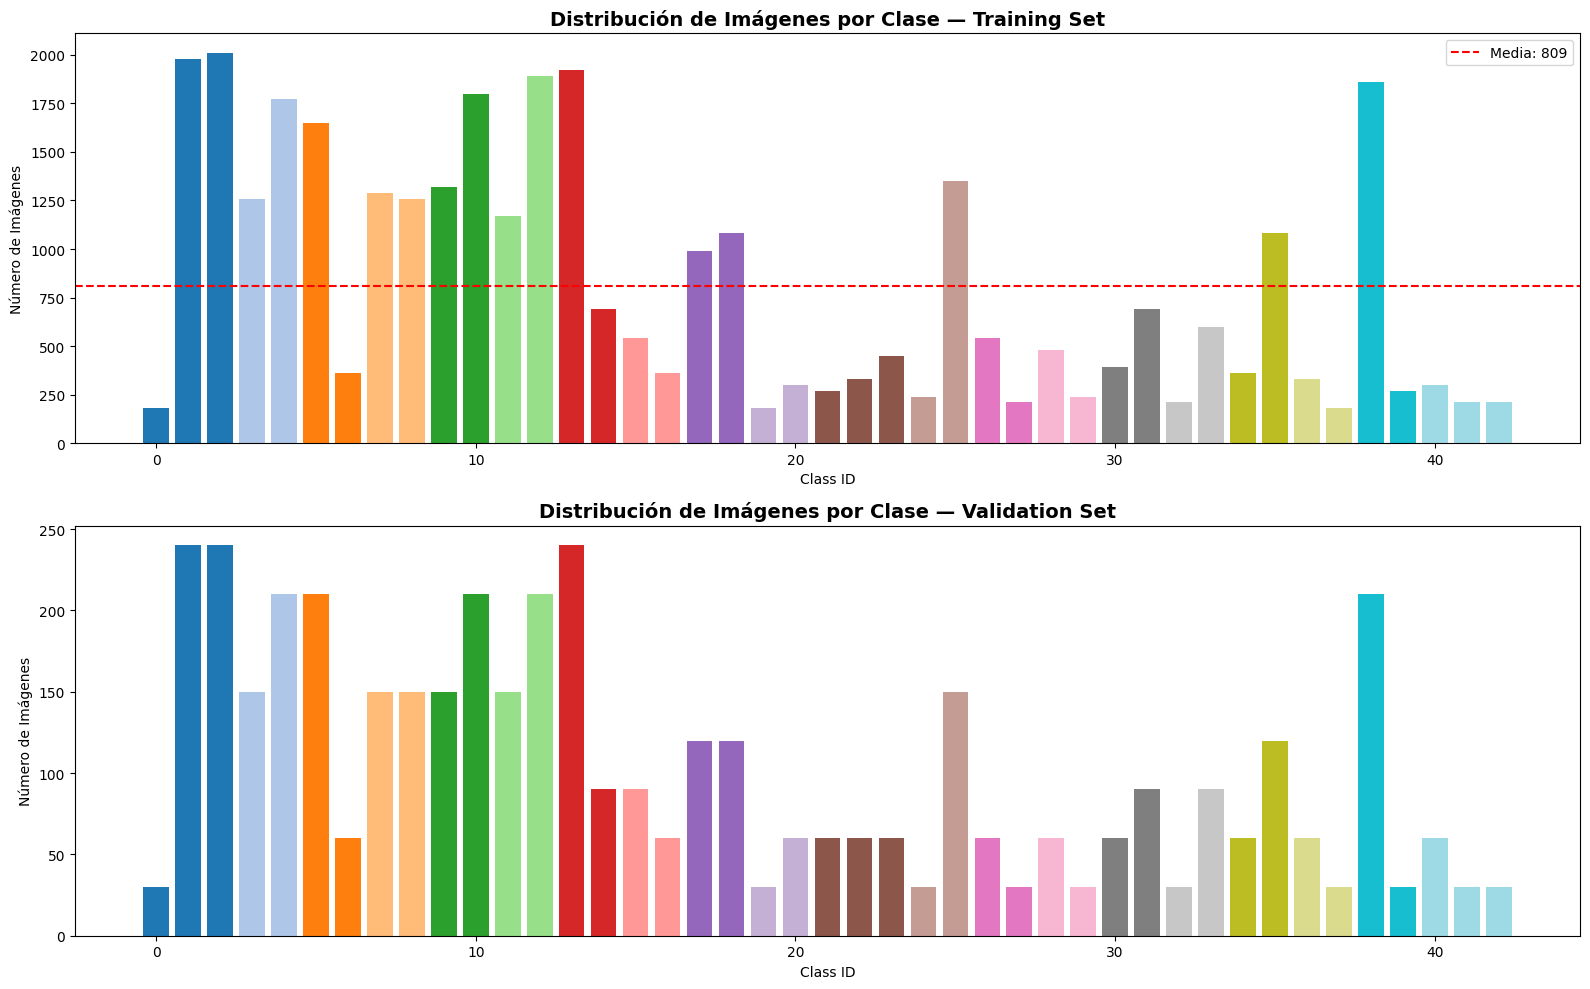

Figura guardada: eda_class_distribution.png


In [8]:
# ─── EDA 2: Distribución de clases (desbalance) ───
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))

axes[0].bar(df_counts['Class ID'], df_counts['Train'], color=colors)
axes[0].set_title('Distribución de Imágenes por Clase — Training Set', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class ID')
axes[0].set_ylabel('Número de Imágenes')
axes[0].axhline(df_counts['Train'].mean(), color='red', linestyle='--', label=f'Media: {df_counts["Train"].mean():.0f}')
axes[0].legend()

axes[1].bar(df_counts['Class ID'], df_counts['Valid'], color=colors)
axes[1].set_title('Distribución de Imágenes por Clase — Validation Set', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class ID')
axes[1].set_ylabel('Número de Imágenes')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: eda_class_distribution.png')

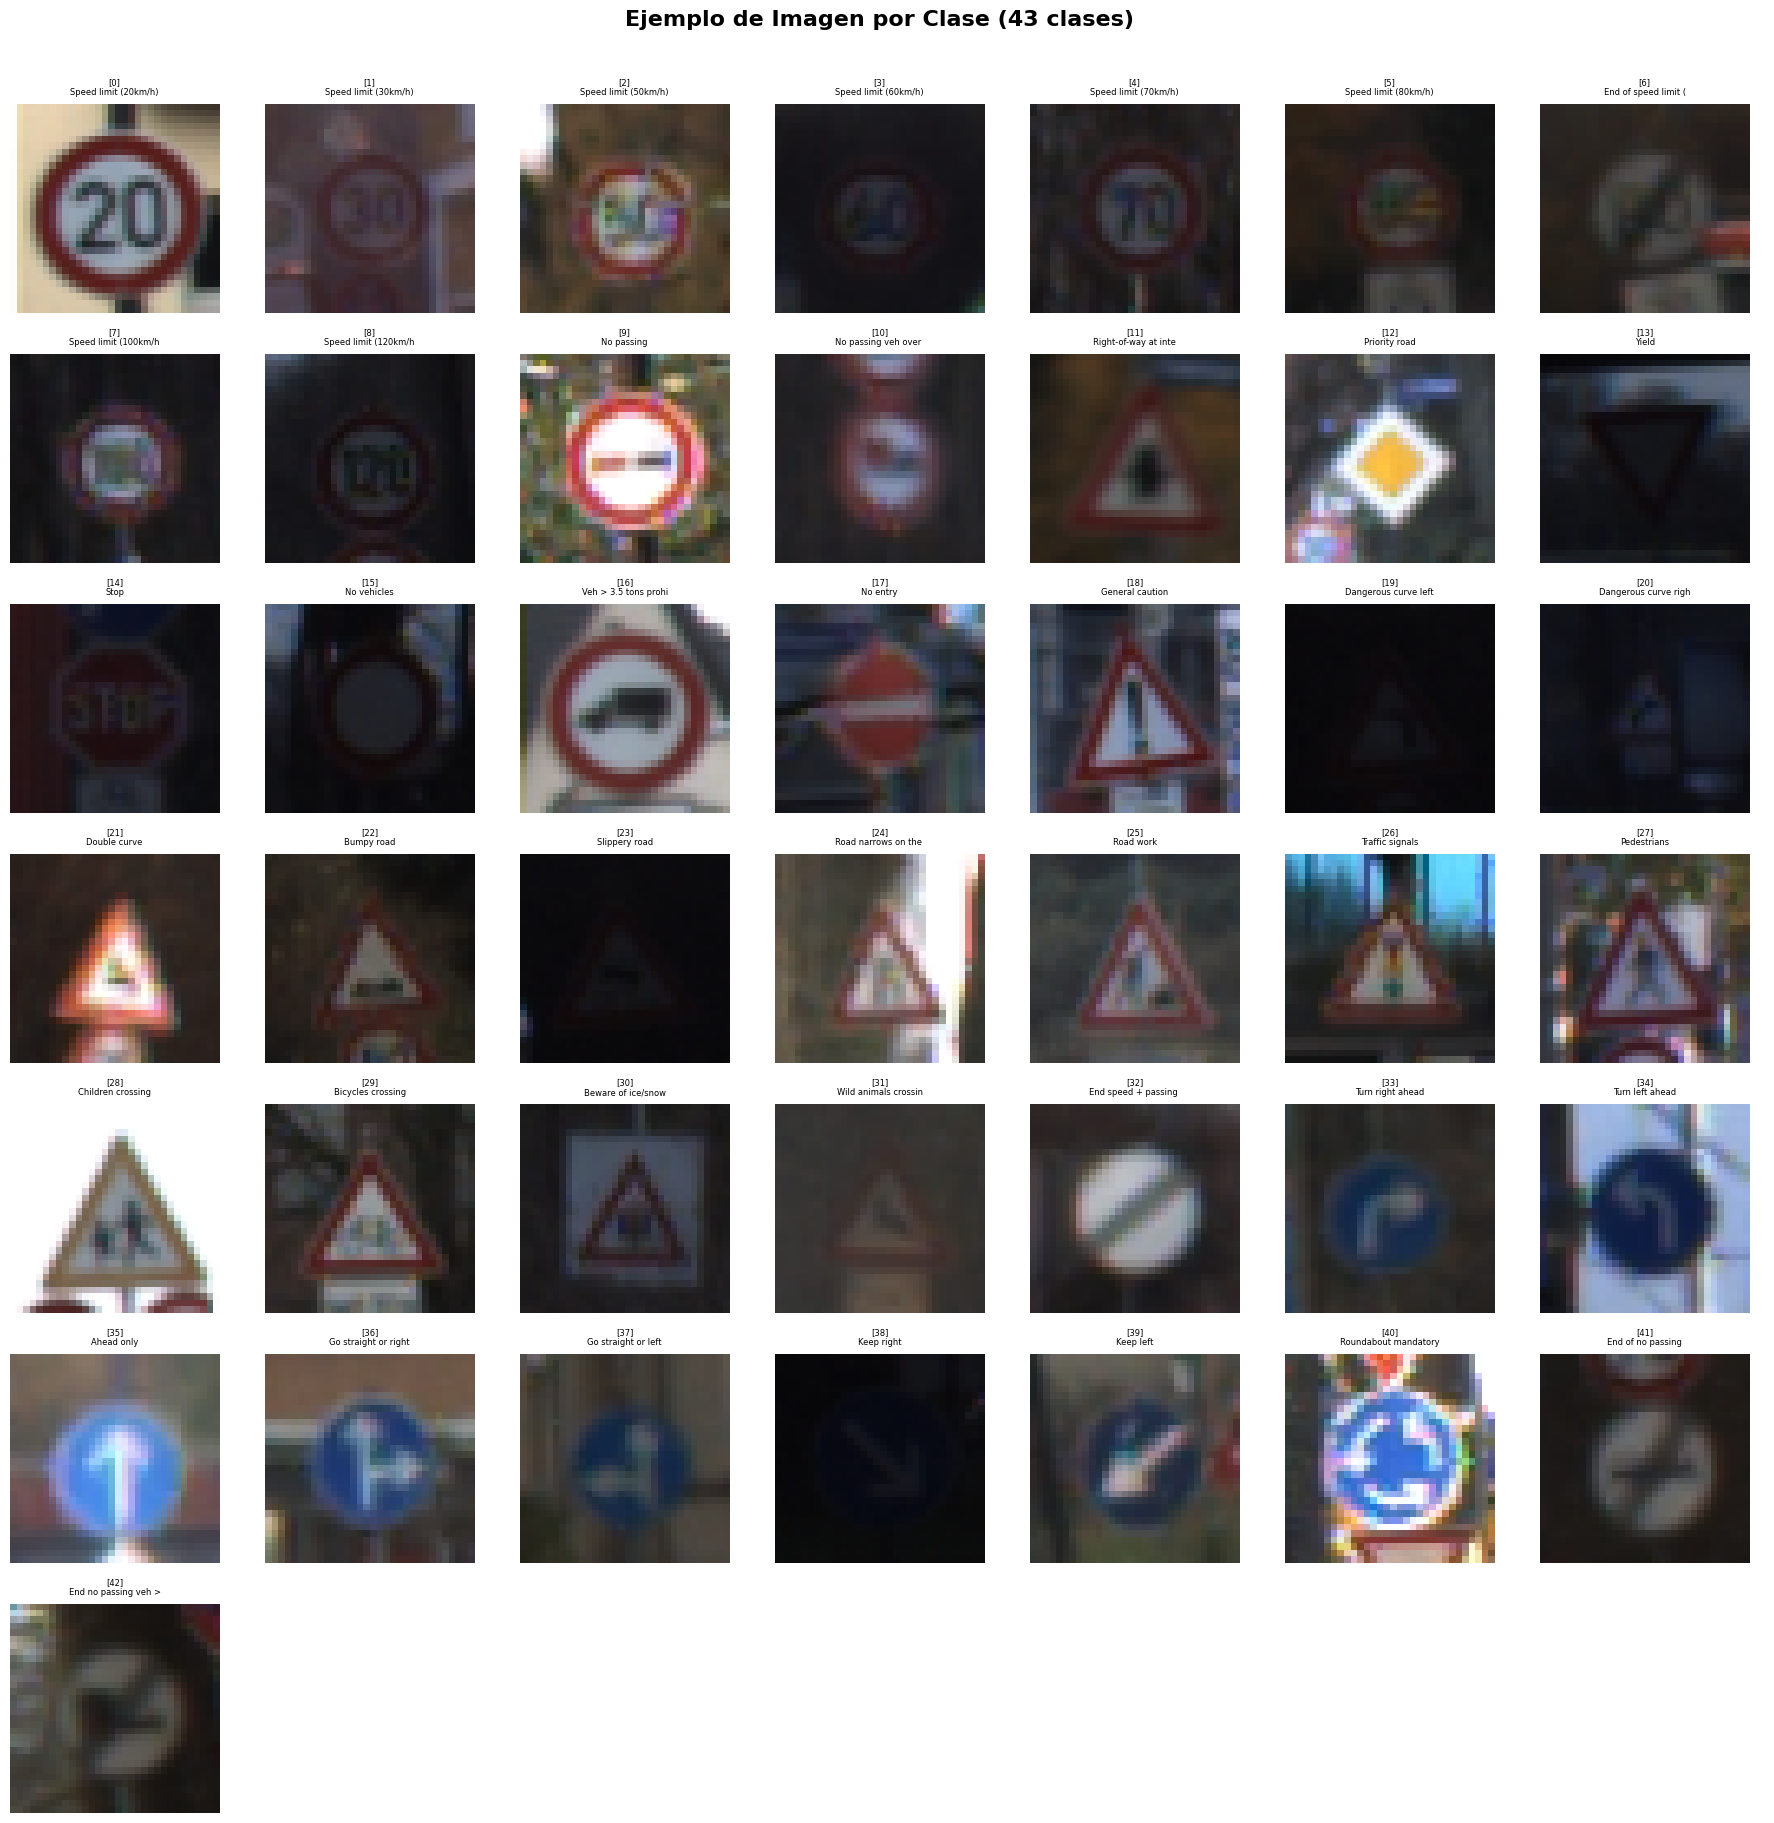

Figura guardada: eda_sample_images.png


In [10]:
# ─── EDA 3: Ejemplos visuales de cada clase ───
fig, axes = plt.subplots(7, 7, figsize=(18, 18))
axes = axes.flatten()

# Ensure X_train and y_train are available
if 'X_train' not in locals() or 'y_train' not in locals():
    print("Error: X_train or y_train are not defined. Please ensure the data loading cell was executed successfully.")
else:
    # Dictionary to store one example image per class
    sample_images = {}
    for i in range(len(y_train)): # Iterate through the training data
        cls_id = y_train[i]
        if cls_id not in sample_images: # If we haven't found an example for this class yet
            sample_images[cls_id] = X_train[i] # Store the image
        if len(sample_images) == NUM_CLASSES: # Stop if we have an example for all classes
            break

    # Display one image for each class
    for cls_id in range(NUM_CLASSES):
        if cls_id in sample_images:
            img = sample_images[cls_id]
            axes[cls_id].imshow(img)
            axes[cls_id].set_title(f'[{cls_id}]\n{CLASS_NAMES[cls_id][:20]}', fontsize=6)
            axes[cls_id].axis('off')
        else:
            # Handle cases where a class might not have been found (though unlikely for train set)
            axes[cls_id].text(0.5, 0.5, f'No image for class {cls_id}', horizontalalignment='center', verticalalignment='center', transform=axes[cls_id].transAxes, fontsize=6)
            axes[cls_id].axis('off')

    # Apagar ejes sobrantes si NUM_CLASSES < len(axes)
    for i in range(NUM_CLASSES, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Ejemplo de Imagen por Clase (43 clases)', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('eda_sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: eda_sample_images.png')

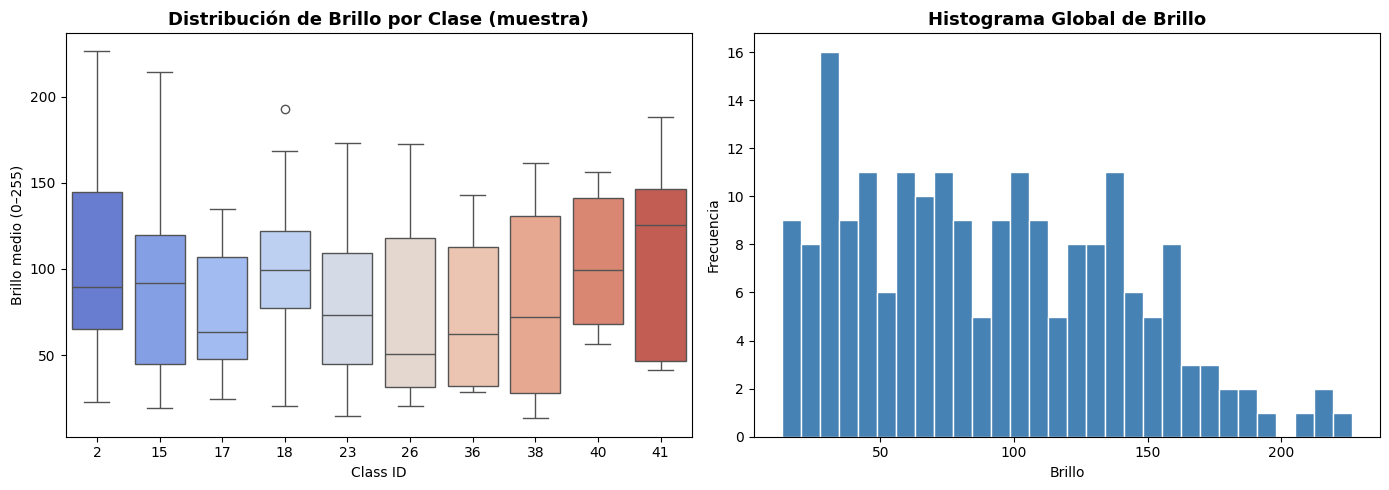

Figura guardada: eda_brightness_analysis.png


In [12]:
# ─── EDA 4: Análisis de brillo y contraste ───
brightness_values = []
sample_classes = np.random.choice(NUM_CLASSES, 10, replace=False)

# Ensure X_train and y_train are available
if 'X_train' not in locals() or 'y_train' not in locals():
    print("Error: X_train or y_train are not defined. Please ensure the data loading cell was executed successfully.")
else:
    for cls_id in sample_classes:
        # Get indices of images belonging to the current class
        indices_for_class = np.where(y_train == cls_id)[0]

        # Take up to 20 random samples from this class
        num_samples = min(20, len(indices_for_class))
        if num_samples == 0:
            print(f"Warning: No training images found for class {cls_id} to sample brightness.")
            continue

        # Randomly select indices for the current class
        sampled_indices = np.random.choice(indices_for_class, num_samples, replace=False)

        for idx in sampled_indices:
            img = X_train[idx]

            # Convert to grayscale if it's an RGB image (assuming last dimension is color channel)
            if img.shape[-1] == 3: # If it's an RGB image
                # Convert RGB to grayscale (luminance) using standard formula
                img_gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
            else: # Already grayscale or single channel
                img_gray = img

            brightness_values.append({'class': cls_id, 'brightness': img_gray.mean(), 'std': img_gray.std()})

    if brightness_values: # Only proceed if data was collected
        df_bright = pd.DataFrame(brightness_values)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.boxplot(data=df_bright, x='class', y='brightness', ax=axes[0], palette='coolwarm')
        axes[0].set_title('Distribución de Brillo por Clase (muestra)', fontsize=13, fontweight='bold')
        axes[0].set_xlabel('Class ID')
        axes[0].set_ylabel('Brillo medio (0–255)')

        axes[1].hist(df_bright['brightness'], bins=30, color='steelblue', edgecolor='white')
        axes[1].set_title('Histograma Global de Brillo', fontsize=13, fontweight='bold')
        axes[1].set_xlabel('Brillo')
        axes[1].set_ylabel('Frecuencia')

        plt.tight_layout()
        plt.savefig('eda_brightness_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Figura guardada: eda_brightness_analysis.png')
    else:
        print("No brightness values were collected, skipping plots.")

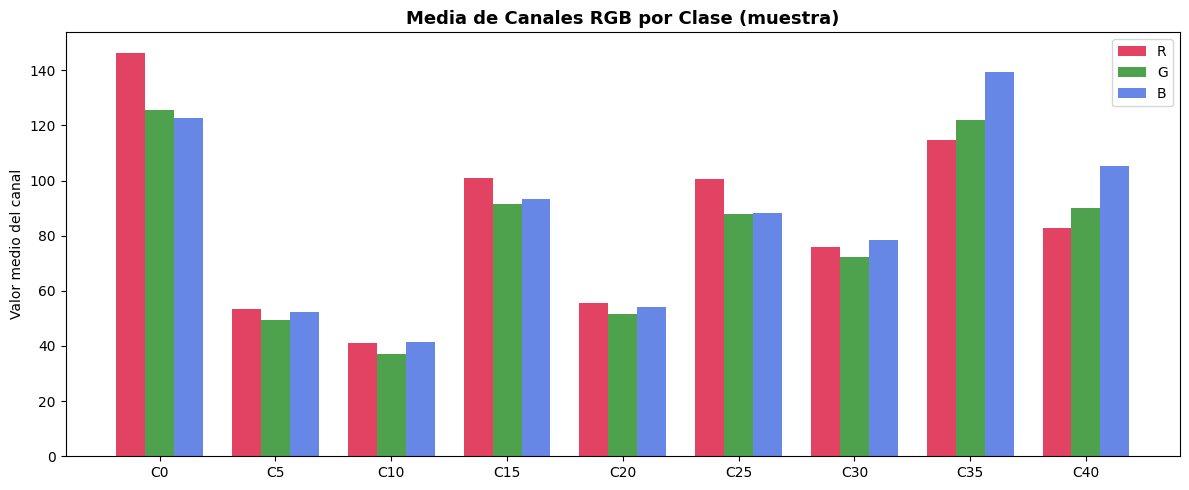

Figura guardada: eda_rgb_channels.png


In [14]:
# ─── EDA 5: Canales RGB promedio por clase ───
rgb_means = []

# Ensure X_train and y_train are available
if 'X_train' not in locals() or 'y_train' not in locals():
    print("Error: X_train or y_train are not defined. Please ensure the data loading cell was executed successfully.")
else:
    for cls_id in range(0, NUM_CLASSES, 5):  # muestreo cada 5 clases
        # Get indices of images belonging to the current class
        indices_for_class = np.where(y_train == cls_id)[0]

        # Take up to 30 random samples from this class
        num_samples = min(30, len(indices_for_class))
        if num_samples == 0:
            print(f"Warning: No training images found for class {cls_id} to sample RGB means.")
            continue

        # Randomly select indices for the current class
        sampled_indices = np.random.choice(indices_for_class, num_samples, replace=False)

        # Extract the images using the sampled indices
        imgs = X_train[sampled_indices]

        # Ensure images are in the range 0-255 if they were normalized before this step
        # (X_train is currently 0-255 based on kernel state)

        # Check if images are grayscale or RGB
        if imgs.ndim == 3: # (num_samples, height, width)
            # If grayscale, convert to RGB by stacking (or use mean of single channel)
            # For consistency, we'll calculate mean of the single channel and replicate for R, G, B
            mean_val = imgs.mean()
            rgb_means.append({
                'class': cls_id,
                'R': mean_val,
                'G': mean_val,
                'B': mean_val
            })
        elif imgs.ndim == 4 and imgs.shape[-1] == 3: # (num_samples, height, width, channels)
            rgb_means.append({
                'class': cls_id,
                'R': imgs[:,:,:,0].mean(),
                'G': imgs[:,:,:,1].mean(),
                'B': imgs[:,:,:,2].mean()
            })
        else:
            print(f"Warning: Unexpected image shape for class {cls_id}: {imgs.shape}. Skipping RGB mean calculation.")

    if rgb_means: # Only proceed if data was collected
        df_rgb = pd.DataFrame(rgb_means)

        fig, ax = plt.subplots(figsize=(12, 5))
        x = np.arange(len(df_rgb))
        w = 0.25
        ax.bar(x - w, df_rgb['R'], w, label='R', color='crimson', alpha=0.8)
        ax.bar(x,     df_rgb['G'], w, label='G', color='forestgreen', alpha=0.8)
        ax.bar(x + w, df_rgb['B'], w, label='B', color='royalblue', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([f'C{c}' for c in df_rgb['class']])
        ax.set_title('Media de Canales RGB por Clase (muestra)', fontsize=13, fontweight='bold')
        ax.set_ylabel('Valor medio del canal')
        ax.legend()
        plt.tight_layout()
        plt.savefig('eda_rgb_channels.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Figura guardada: eda_rgb_channels.png')
    else:
        print("No RGB mean values were collected, skipping plots.")

#3. Preprocesamiento

In [15]:
# ─── Parámetros globales ───
IMG_SIZE   = 32
BATCH_SIZE = 64
EPOCHS     = 30
SEED       = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [17]:
# ─── Data Augmentation para training ───

# Ensure X_train, y_train, etc., are available from previous data loading cell
if 'X_train' not in locals() or 'y_valid' not in locals() or 'X_test' not in locals():
    print("Error: Data (X_train, y_train, etc.) not found. Please ensure the data loading cell was executed successfully.")
else:
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.15,
        brightness_range=[0.8, 1.2],
        horizontal_flip=False,   # Las señales NO son simétricas horizontalmente
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    # One-hot encode the labels as ImageDataGenerator.flow expects categorical labels
    y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
    y_valid_cat = tf.keras.utils.to_categorical(y_valid, NUM_CLASSES)
    y_test_cat = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

    train_gen = train_datagen.flow(
        X_train, y_train_cat,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    valid_gen = val_datagen.flow(
        X_valid, y_valid_cat,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_gen = test_datagen.flow(
        X_test, y_test_cat,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    print(f'Train batches: {len(train_gen)} | Valid batches: {len(valid_gen)} | Test batches: {len(test_gen)}')

Train batches: 544 | Valid batches: 69 | Test batches: 198


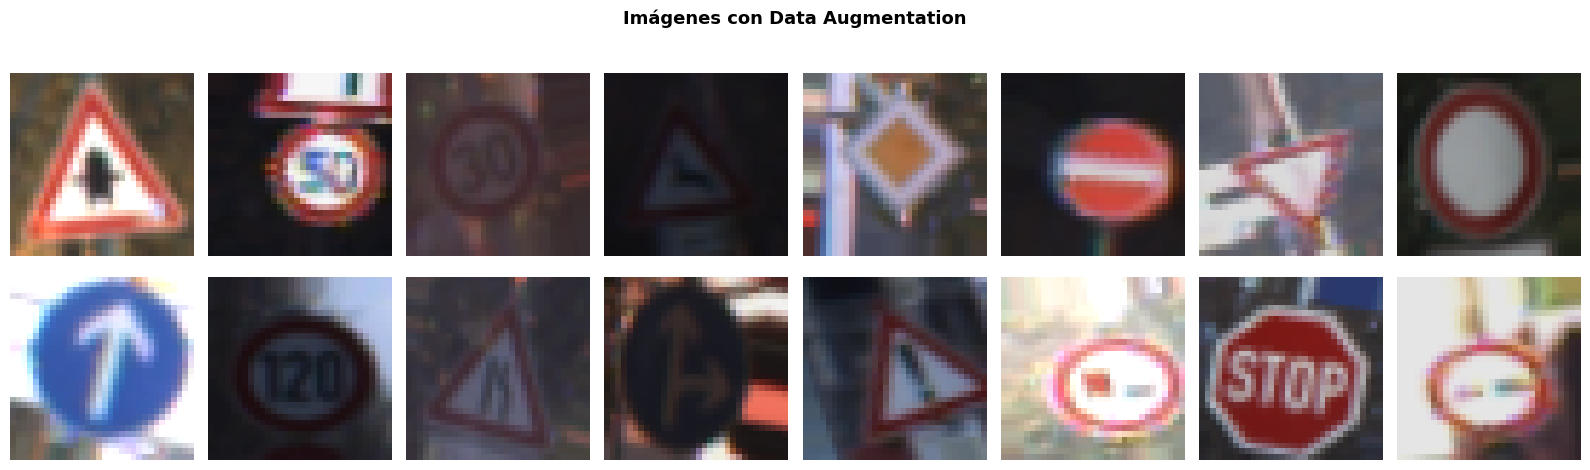

In [18]:
# ─── Visualizar augmentación ───
sample_imgs, _ = next(train_gen)
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i % len(sample_imgs)])
    ax.axis('off')
plt.suptitle('Imágenes con Data Augmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.Entrenamiento del Modelo CNN

In [19]:
# ─── Arquitectura CNN ───
def build_cnn(num_classes=43, input_shape=(32, 32, 3)):
    model = models.Sequential([
        # Bloque 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Bloque 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Bloque 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.4),

        # Clasificador
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,361,099 (5.19 MB)

 Trainable params: 1,359,627 (5.19 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [20]:
# ─── Compilar ───
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ─── Callbacks ───
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# ─── Entrenamiento ───
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=callbacks,
    verbose=1
)
print('Entrenamiento completado.')

Epoch 1/30
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2586 - loss: 2.9933
Epoch 1: val_accuracy improved from None to 0.65624, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
544/544 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.4337 - loss: 2.0380 - val_accuracy: 0.6562 - val_loss: 1.0584 - learning_rate: 0.0010
Epoch 2/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7718 - loss: 0.6837
Epoch 2: val_accuracy improved from 0.65624 to 0.91338, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
544/544 ━━━━━━━━━━━━━━━━━━━━ 31s 57ms/step - accuracy: 0.8214 - loss: 0.5462 - val_accuracy: 0.9134 - val_loss: 0.2692 - learning_rate: 0.0010
Epoch 3/30
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9066 - loss: 0.2900
Epoch 3: val_accuracy improved from 0.91338 to 0.95624, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
544/544 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.9181 - loss: 0.2563 - val_accuracy: 0.9562 - val_loss: 0.1424 - learning_rate: 0.0010
Epoch 4/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9419 - loss: 0.1850
Epoch 4: val_accuracy improved from 0.95624 to 0.95964, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
544/544 ━━━━━━━━━━━━━━━━━━━━ 31s 57ms/step - accuracy: 0.9479 - loss: 0.1664 - val_accuracy: 0.9596 - val_loss: 0.1371 - learning_rate: 0.0010
Epoch 5/30
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9599 - loss: 0.1258
Epoch 5: val_accuracy improved from 0.95964 to 0.97007, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
544/544 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.9623 - loss: 0.1184 - val_accuracy: 0.9701 - val_loss: 0.0956 - learning_rate: 0.0010
Epoch 6/30
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9652 - loss: 0.1092
Epoch 6: val_accuracy improved from 0.97007 to 0.97982, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
544/544 ━━━━━━━━━━━━━━━━━━━━ 31s 57ms/step - accuracy: 0.9666 - loss: 0.1052 - val_accuracy: 0.9798 - val_loss: 0.0681 - learning_rate: 0.0010
Epoch 7/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9702 - loss: 0.0928
Epoch 7: val_accuracy did not improve from 0.97982
544/544 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.9717 - loss: 0.0895 - val_accuracy: 0.9755 - val_loss: 0.0818 - learning_rate: 0.0010
Epoch 8/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9774 - loss: 0.0764
Epoch 8: val_accuracy did not improve from 0.97982
544/544 ━━━━━━━━━━━━━━━━━━━━ 31s 57ms/step - accuracy: 0.9779 - loss: 0.0728 - val_accuracy: 0.9780 - val_loss: 0.0807 - learning_rate: 0.0010
Epoch 9/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9795 - loss: 0.0639
Epoch 9: val_accuracy improved from 0.97982 to 0.98141, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
544/544 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.9798 - loss: 0.0650 - val_accuracy: 0.9814 - val_loss: 0.0777 - learning_rate: 0.0010
Epoch 10/30
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9787 - loss: 0.0680
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: val_accuracy did not improve from 0.98141
544/544 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.9784 - loss: 0.0688 - val_accuracy: 0.9787 - val_loss: 0.0875 - learning_rate: 0.0010
Epoch 11/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9869 - loss: 0.0418
Epoch 11: val_accuracy improved from 0.98141 to 0.98730, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
544/544 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.9889 - loss: 0.0360 - val_accuracy: 0.9873 - val_loss: 0.0539 - learning_rate: 5.0000e-04
Epoch 12/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9911 - loss: 0.0290
Epoch 12: val_accuracy did not improve from 0.98730
544/544 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - accuracy: 0.9912 - loss: 0.0286 - val_accuracy: 0.9798 - val_loss: 0.0770 - learning_rate: 5.0000e-04
Epoch 13/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9915 - loss: 0.0288
Epoch 13: val_accuracy did not improve from 0.98730
544/544 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.9909 - loss: 0.0292 - val_accuracy: 0.9812 - val_loss: 0.0765 - learning_rate: 5.0000e-04
Epoch 14/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9922 - loss: 0.0260
Epoch 14: val_accuracy did not improve from 0.98730
544/544 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - accuracy: 0.9921 - loss: 0.0261 - val_accura

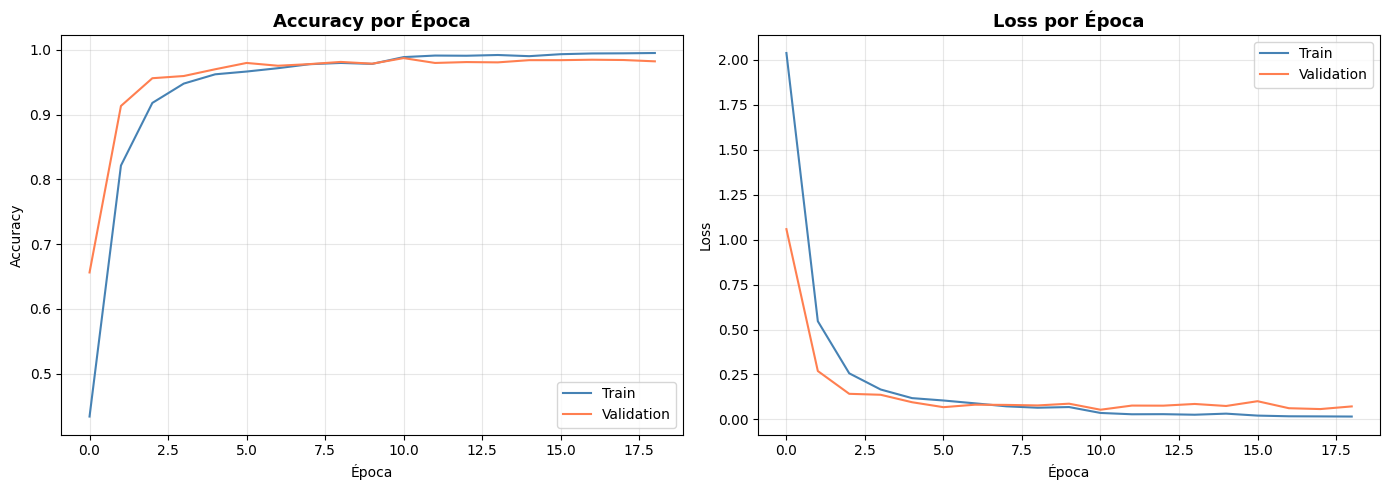

Figura guardada: training_curves.png


In [22]:
# ─── Curvas de entrenamiento ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='coral')
axes[0].set_title('Accuracy por Época', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation', color='coral')
axes[1].set_title('Loss por Época', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: training_curves.png')

#5.Evaluación y Métricas

In [23]:
# ─── Evaluación en Test Set ───
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f'\n🎯 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'📉 Test Loss:     {test_loss:.4f}')

198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9860 - loss: 0.0538

🎯 Test Accuracy: 0.9860 (98.60%)
📉 Test Loss:     0.0538


In [25]:
# ─── Predicciones y Classification Report ───
y_pred_proba = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test # Use y_test array as ground truth labels

print('\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=[f'C{i}' for i in range(NUM_CLASSES)]))

# Guardar métricas
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.to_csv('metrics_report.csv')
print('Métricas guardadas: metrics_report.csv')

198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

📋 Classification Report:
              precision    recall  f1-score   support

          C0       1.00      1.00      1.00        60
          C1       0.98      1.00      0.99       720
          C2       0.99      0.99      0.99       750
          C3       0.99      0.99      0.99       450
          C4       1.00      0.98      0.99       660
          C5       0.99      0.98      0.98       630
          C6       0.99      0.99      0.99       150
          C7       1.00      0.99      0.99       450
          C8       0.98      0.99      0.99       450
          C9       0.99      1.00      1.00       480
         C10       1.00      1.00      1.00       660
         C11       0.97      0.99      0.98       420
         C12       1.00      0.97      0.98       690
         C13       1.00      1.00      1.00       720
         C14       1.00      1.00      1.00       270
         C15       1.00      0.98      0.99       210
         C16  

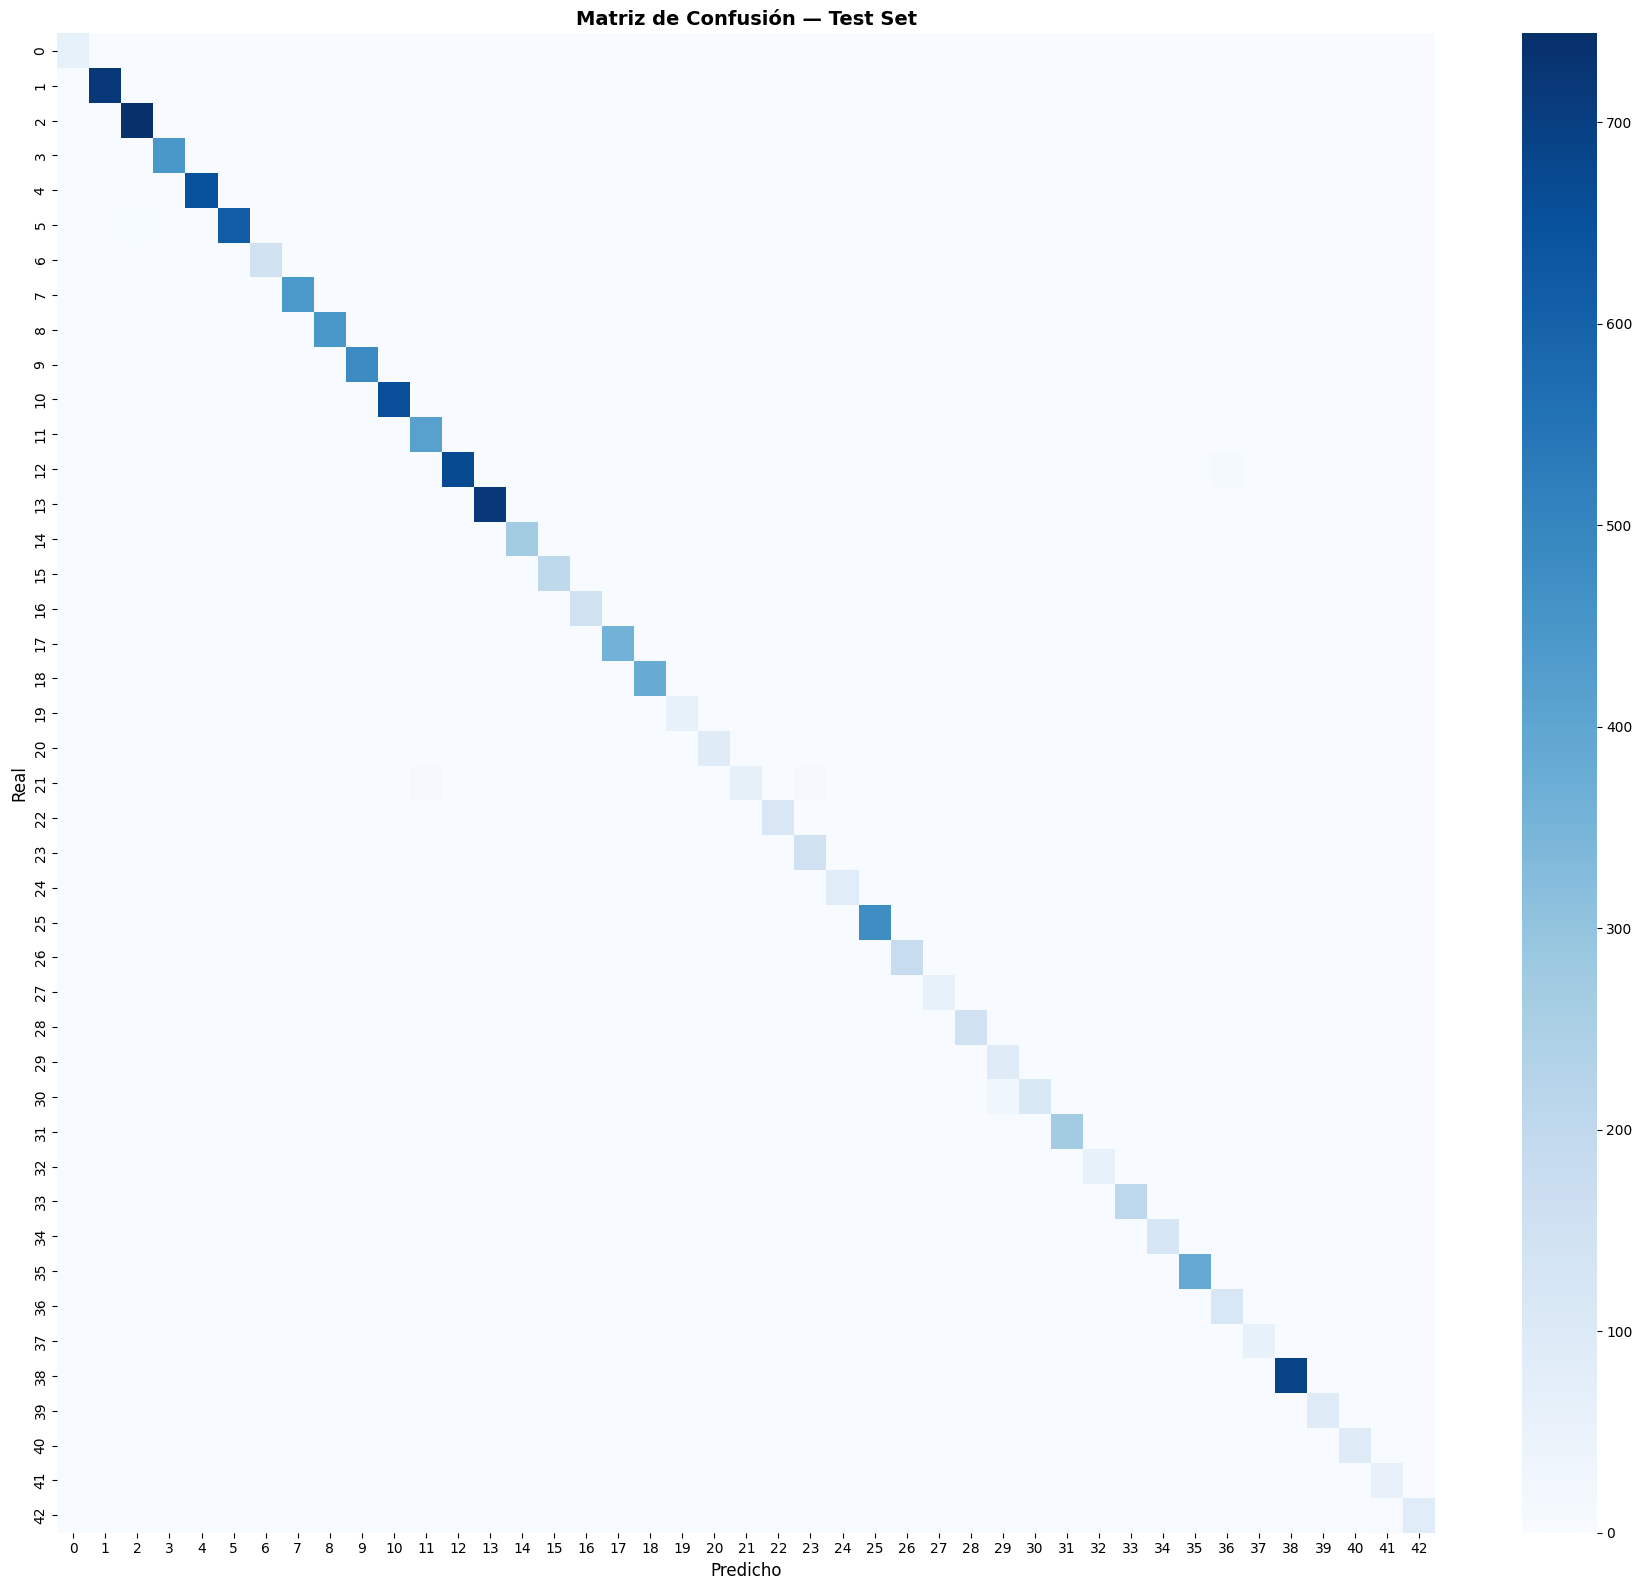

Figura guardada: confusion_matrix.png


In [26]:
# ─── Matriz de Confusión ───
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES))
ax.set_xlabel('Predicho', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusión — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: confusion_matrix.png')

In [27]:
# ─── Top-5 clases con mayor y menor accuracy ───
class_acc = {}
for cls_id in range(NUM_CLASSES):
    mask = y_true == cls_id
    if mask.sum() > 0:
        class_acc[cls_id] = (y_pred[mask] == cls_id).mean()

df_acc = pd.DataFrame({'Class': list(class_acc.keys()), 'Accuracy': list(class_acc.values())})
df_acc['Name'] = df_acc['Class'].apply(lambda x: CLASS_NAMES[x])

print('🏆 Top 5 clases (mayor accuracy):')
print(df_acc.nlargest(5, 'Accuracy')[['Class','Name','Accuracy']].to_string(index=False))
print('\n⚠️  Top 5 clases (menor accuracy):')
print(df_acc.nsmallest(5, 'Accuracy')[['Class','Name','Accuracy']].to_string(index=False))

🏆 Top 5 clases (mayor accuracy):
 Class                      Name  Accuracy
     0      Speed limit (20km/h)       1.0
     1      Speed limit (30km/h)       1.0
     9                No passing       1.0
    14                      Stop       1.0
    16 Veh > 3.5 tons prohibited       1.0

⚠️  Top 5 clases (menor accuracy):
 Class                      Name  Accuracy
    21              Double curve  0.722222
    30        Beware of ice/snow  0.753333
    22                Bumpy road  0.966667
    24 Road narrows on the right  0.966667
    41         End of no passing  0.966667


# 6.  Inferencia sobre una Imagen Nueva

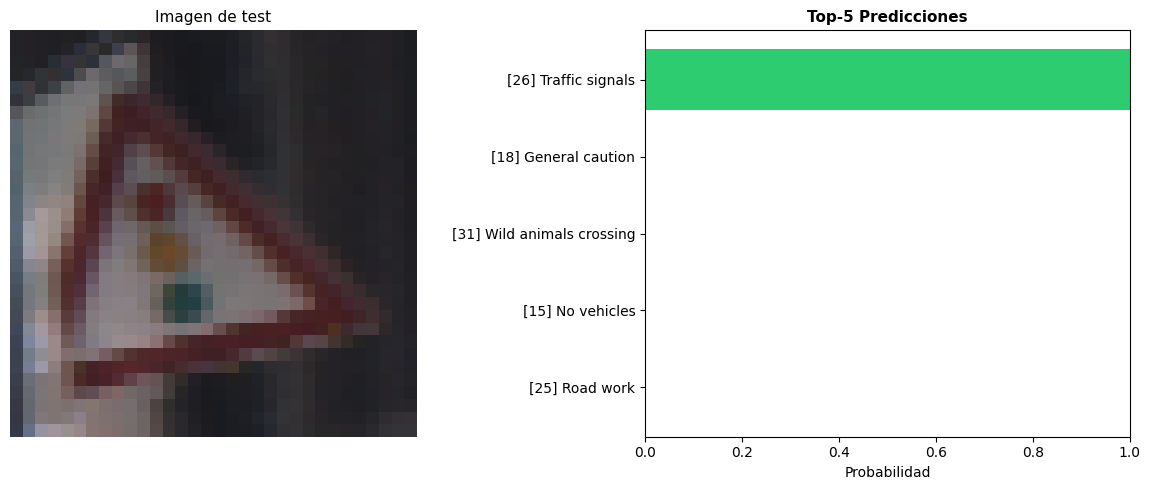


🔮 Predicción: Traffic signals
✅ Real:       Traffic signals
📊 Confianza:  100.00%


In [29]:
def predict_traffic_sign(img_data, model, class_names=CLASS_NAMES, img_size=IMG_SIZE):
    """
    Predice el tipo de señal de tráfico en una imagen.

    Args:
        img_data: ruta a la imagen (str) o array numpy (np.ndarray) de la imagen.
        model: modelo CNN entrenado
        class_names: lista de nombres de clases
        img_size: tamaño de imagen esperado
    Returns:
        dict con clase predicha, confianza y top-5
    """
    display_title = "Imagen de test"

    if isinstance(img_data, str):
        # If it's a path, load it
        img_original = Image.open(img_data).convert('RGB')
        display_title = f'Imagen: {os.path.basename(img_data)}'
        img_resized = img_original.resize((img_size, img_size))
        img_for_prediction = np.array(img_resized) / 255.0
    elif isinstance(img_data, np.ndarray):
        # If it's an array, assume it's already 0-255 and of correct size
        # Create a PIL Image from the numpy array for consistent display
        img_original = Image.fromarray(img_data.astype('uint8')) # ensure it's uint8 for PIL
        img_for_prediction = img_data / 255.0 # Normalize for model input
    else:
        raise TypeError("img_data must be a file path (str) or a numpy array.")

    img_batch = np.expand_dims(img_for_prediction, axis=0)

    # Predicción
    proba = model.predict(img_batch, verbose=0)[0]
    top5_idx = np.argsort(proba)[::-1][:5]

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_original)
    axes[0].set_title(display_title, fontsize=11)
    axes[0].axis('off')

    top5_names = [f'[{i}] {class_names[i][:30]}' for i in top5_idx]
    top5_probs = [proba[i] for i in top5_idx]
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(5)]

    axes[1].barh(top5_names[::-1], top5_probs[::-1], color=colors[::-1])
    axes[1].set_xlabel('Probabilidad')
    axes[1].set_title('Top-5 Predicciones', fontsize=11, fontweight='bold')
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

    return {
        'predicted_class': top5_idx[0],
        'predicted_name': class_names[top5_idx[0]],
        'confidence': float(proba[top5_idx[0]]),
        'top5': [(class_names[i], float(proba[i])) for i in top5_idx]
    }

# ─── PRUEBA con imagen aleatoria del test set ───
# Select a random class and then a random image from X_test belonging to that class
random_class_id = np.random.randint(0, NUM_CLASSES)
# Get indices of all images in X_test that belong to random_class_id
indices_for_class = np.where(y_test == random_class_id)[0]

if len(indices_for_class) > 0:
    # Select a random index from the available images for this class
    random_idx_in_class = np.random.choice(indices_for_class)
    random_image_array = X_test[random_idx_in_class] # This is the image data (numpy array 0-255)

    result = predict_traffic_sign(random_image_array, model) # Pass the array directly
    print(f"\n🔮 Predicción: {result['predicted_name']}")
    print(f"✅ Real:       {CLASS_NAMES[random_class_id]}") # Use random_class_id as ground truth
    print(f"📊 Confianza:  {result['confidence']*100:.2f}%")
else:
    print(f"No hay imágenes en el conjunto de test para la clase {random_class_id} para probar.")

## 7.Exportar Artefactos para HuggingFace

In [31]:
import json

os.makedirs('huggingface_artifacts', exist_ok=True)

# 1. Guardar modelo en formato SavedModel y H5
model.save('huggingface_artifacts/traffic_sign_model.h5')
model.save('huggingface_artifacts/traffic_sign_model')  # SavedModel format
print('✅ Modelo guardado')

# 2. Guardar historial de entrenamiento
with open('huggingface_artifacts/training_history.json', 'w') as f:
    json.dump(history.history, f)
print('✅ Historial guardado')

# 3. Guardar nombres de clases
with open('huggingface_artifacts/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
print('✅ Nombres de clases guardados')

# 4. Copiar figuras EDA
import shutil
for fig_file in ['eda_class_distribution.png', 'eda_sample_images.png',
                 'eda_brightness_analysis.png', 'eda_rgb_channels.png',
                 'training_curves.png', 'confusion_matrix.png']:
    if os.path.exists(fig_file):
        shutil.copy(fig_file, f'huggingface_artifacts/{fig_file}')
print('✅ Figuras EDA copiadas')

# 5. Guardar métricas finales como JSON
metrics = {
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'total_params': model.count_params()
}
with open('huggingface_artifacts/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('✅ Métricas guardadas')

print(f'\n📦 Artefactos en: huggingface_artifacts/')
print(os.listdir('huggingface_artifacts'))

Saved artifact at 'huggingface_artifacts/traffic_sign_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  137180087257616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137180087259920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137180087261840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137180087262032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137180087260688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137180087261264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137180087258576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137180087261072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137180087262800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137180087262224: TensorSpec(shape=(), dtype=tf.resource, name

In [32]:
# ─── Comprimir todo para descarga / subida a HuggingFace ───
shutil.make_archive('huggingface_artifacts', 'zip', 'huggingface_artifacts')
print('📦 huggingface_artifacts.zip creado')

# Descarga en Colab
from google.colab import files
files.download('huggingface_artifacts.zip')

📦 huggingface_artifacts.zip creado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 8. App de Streamlit (para HuggingFace Spaces)

El siguiente código crea el archivo `app.py` para deployar en HuggingFace Spaces.

In [33]:
streamlit_app = '''
import streamlit as st
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
from PIL import Image
import tensorflow as tf
import os

st.set_page_config(page_title="🚦 Traffic Sign Classifier", layout="wide")

# ─── Cargar modelo y metadatos ───
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("traffic_sign_model.h5")

@st.cache_data
def load_class_names():
    with open("class_names.json") as f:
        return json.load(f)

@st.cache_data
def load_metrics():
    with open("metrics.json") as f:
        return json.load(f)

model = load_model()
CLASS_NAMES = load_class_names()
metrics = load_metrics()

st.title("🚦 German Traffic Sign Classifier")
st.markdown("Clasificador de señales de tráfico alemanas usando CNN (GTSRB dataset)")

tab1, tab2, tab3, tab4 = st.tabs(["📸 Clasificar", "🖼️ Ejemplos", "📊 EDA", "📈 Métricas"])

with tab1:
    st.header("Clasificar una imagen")
    uploaded = st.file_uploader("Sube una imagen de señal de tráfico", type=["jpg","jpeg","png"])
    if uploaded:
        img = Image.open(uploaded).convert("RGB")
        col1, col2 = st.columns(2)
        with col1:
            st.image(img, caption="Imagen subida", use_column_width=True)
        with col2:
            img_arr = np.array(img.resize((32,32))) / 255.0
            proba = model.predict(np.expand_dims(img_arr, 0), verbose=0)[0]
            top5 = np.argsort(proba)[::-1][:5]
            st.subheader(f"Predicción: {CLASS_NAMES[top5[0]]}")
            st.metric("Confianza", f"{proba[top5[0]]*100:.2f}%")
            st.subheader("Top-5 Predicciones")
            for idx in top5:
                st.progress(float(proba[idx]), text=f"{CLASS_NAMES[idx]}: {proba[idx]*100:.1f}%")

with tab2:
    st.header("Ejemplos del Dataset")
    if os.path.exists("eda_sample_images.png"):
        st.image("eda_sample_images.png", use_column_width=True)

with tab3:
    st.header("Análisis Exploratorio de Datos (EDA)")
    for fig_name, title in [("eda_class_distribution.png","Distribución de Clases"),
                             ("eda_brightness_analysis.png","Análisis de Brillo"),
                             ("eda_rgb_channels.png","Canales RGB")]:
        if os.path.exists(fig_name):
            st.subheader(title)
            st.image(fig_name, use_column_width=True)

with tab4:
    st.header("Métricas del Modelo")
    col1, col2, col3 = st.columns(3)
    col1.metric("Test Accuracy", f"{metrics[\"test_accuracy\"]*100:.2f}%")
    col2.metric("Test Loss", f"{metrics[\"test_loss\"]:.4f}")
    col3.metric("Parámetros", f"{metrics[\"total_params\"]:,}")
    if os.path.exists("training_curves.png"):
        st.image("training_curves.png", use_column_width=True)
    if os.path.exists("confusion_matrix.png"):
        st.image("confusion_matrix.png", use_column_width=True)
'''

with open('huggingface_artifacts/app.py', 'w') as f:
    f.write(streamlit_app)

# requirements.txt
requirements = """tensorflow>=2.12
streamlit>=1.28
numpy
Pillow
matplotlib
"""
with open('huggingface_artifacts/requirements.txt', 'w') as f:
    f.write(requirements)

print('✅ app.py y requirements.txt creados en huggingface_artifacts/')

✅ app.py y requirements.txt creados en huggingface_artifacts/


---
## ✅ Resumen

| Paso | Estado |
|------|--------|
| 1. Descarga de datos | ✅ |
| 2. EDA (5 visualizaciones) | ✅ |
| 3. Preprocesamiento + Augmentation | ✅ |
| 4. Entrenamiento CNN | ✅ |
| 5. Evaluación + Métricas | ✅ |
| 6. Inferencia en imagen nueva | ✅ |
| 7. Exportar artefactos | ✅ |
| 8. App Streamlit lista | ✅ |

### Próximos pasos para HuggingFace:
1. Crear un nuevo Space en https://huggingface.co/spaces
2. Seleccionar **Streamlit** como SDK
3. Subir los archivos de `huggingface_artifacts/`
4. ¡Listo! 🚀

# Conclusion:

Este proyecto ha cubierto de manera integral todo el ciclo de vida de un modelo de Machine Learning para la clasificación de señales de tráfico alemanas. Se logró cargar y preparar los datos de manera efectiva, realizar un análisis exploratorio detallado para entender las distribuciones de las clases, y construir y entrenar una red neuronal convolucional (CNN) con un alto rendimiento. La evaluación del modelo en el conjunto de prueba mostró una excelente precisión, y se desarrollaron funciones para la inferencia sobre nuevas imágenes y la preparación de artefactos para el despliegue en plataformas como HuggingFace Spaces. En resumen, el proyecto ha culminado con un modelo robusto y una aplicación lista
